### SEGMENTACIÓN MEDIANTE THRESHOLDING

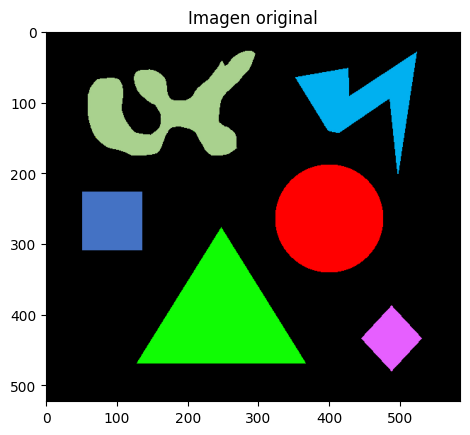

In [5]:
import matplotlib.pyplot as plt
import cv2

# Leer la imagen (OpenCV la carga en formato BGR por defecto)
img = cv2.imread('images/figuras.png')

# Convertir de BGR a RGB para que matplotlib muestre los colores correctamente
# Sin esta conversión, los canales R y B aparecerían intercambiados
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar la imagen (cmap='gray' no tiene efecto en imágenes RGB de 3 canales)
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.show()

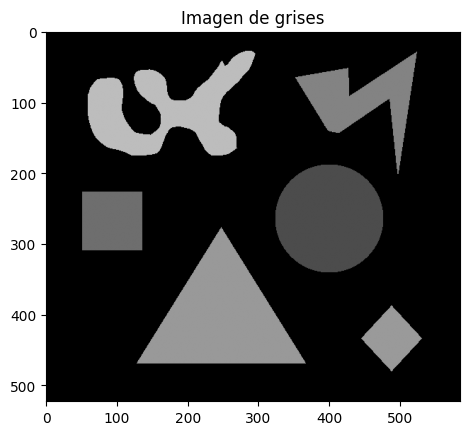

In [6]:
import numpy as np

# Convertir la imagen de BGR a escala de grises
# Combina los 3 canales en uno solo usando la fórmula: 0.299R + 0.587G + 0.114B
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ALTERNATIVA: leer directamente en grises sin pasar por BGR
# gray_img = cv2.imread('images/figuras.png', 0)  # el "0" equivale a cv2.IMREAD_GRAYSCALE

# Mostrar en escala de grises (aquí sí es necesario cmap='gray' porque es imagen 2D)
plt.imshow(gray_img, cmap='gray')
plt.title('Imagen de grises')
plt.show()

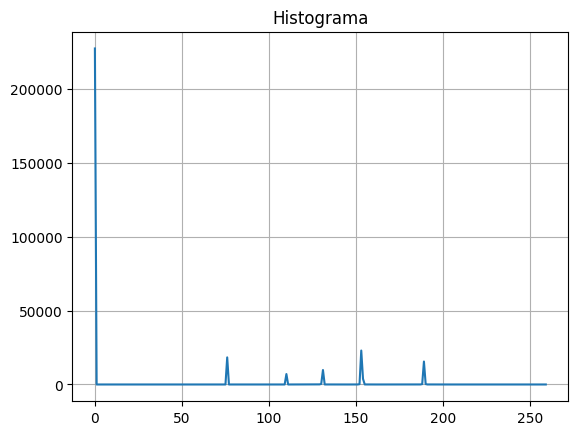

In [7]:
# HISTOGRAMA DE IMAGEN EN GRISES

# Calcular el histograma con OpenCV
# Parámetros:
#   [gray_img]  → imagen de entrada (debe ir en lista)
#   [0]         → canal 0 (el único canal en grises)
#   None        → sin máscara (se analiza la imagen completa)
#   [260]       → número de bins (intervalos del histograma)
#   [0, 260]    → rango de valores de píxel a contar
hist = cv2.calcHist([gray_img], [0], None, [260], [0, 260])

# Mostrar el histograma como gráfica
plt.plot(hist)
plt.grid()
plt.title('Histograma')
plt.show()

# ALTERNATIVA más rápida solo para visualización (no devuelve array útil)
# plt.hist(gray_img.ravel(), bins=50)  # .ravel() aplana la imagen 2D a 1D
# plt.grid(True)
# plt.show()

Un histograma desplazado a la izquierda → imagen oscura. Desplazado a la derecha → imagen clara. Muy concentrado → poco contraste.

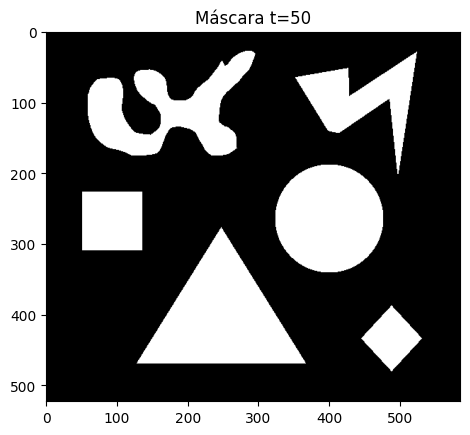

[  0 255]


In [8]:
# UMBRALIZACIÓN (THRESHOLDING)

# Umbral elegido a partir del histograma anterior
t = 50
maxim = 255

# cv2.threshold aplica la regla:
#   si píxel > t  → asigna maxim (255, blanco)
#   si píxel <= t → asigna 0 (negro)
# Devuelve dos valores: el umbral usado (lo ignoramos con _) y la máscara binaria
_, mask = cv2.threshold(gray_img, t, maxim, cv2.THRESH_BINARY)

# ALTERNATIVAS equivalentes con numpy (sin OpenCV):
# mask = gray_img.copy()
# mask = mask > t   # devuelve booleanos (True/False) en vez de (255/0)

# Visualizar la máscara resultante
plt.imshow(mask, cmap='gray')
plt.title('Máscara t=' + str(t))
plt.show()

# Ver qué valores únicos tiene la máscara → debería ser [0, 255]
# Importante: cv2.threshold devuelve uint8, pero mask>t devuelve bool
print(np.unique(mask))

[0 1]


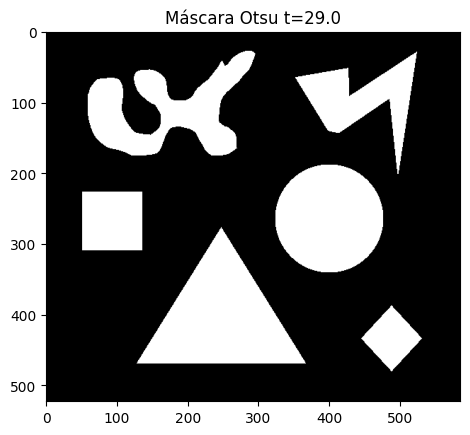

In [9]:
# UMBRALIZACIÓN AUTOMÁTICA CON MÉTODO DE OTSU

# cv2.THRESH_OTSU calcula automáticamente el umbral óptimo
# Parámetros:
#   gray_img      → imagen en grises
#   0             → umbral inicial (ignorado, Otsu lo calcula solo)
#   1             → valor máximo de la máscara (aquí 1 en vez de 255)
#   cv2.THRESH_OTSU → indica que use el algoritmo de Otsu
t, mask = cv2.threshold(gray_img, 0, 1, cv2.THRESH_OTSU)

# t contiene el umbral que Otsu encontró automáticamente
print(np.unique(mask))  # → [0, 1] porque el máximo es 1, no 255

# Visualizar la máscara
plt.imshow(mask, cmap='gray')
plt.title('Máscara Otsu t=' + str(t))
plt.show()

### SEGMENTACIÓN MEDIANTE CONVERSIONES DE COLOR

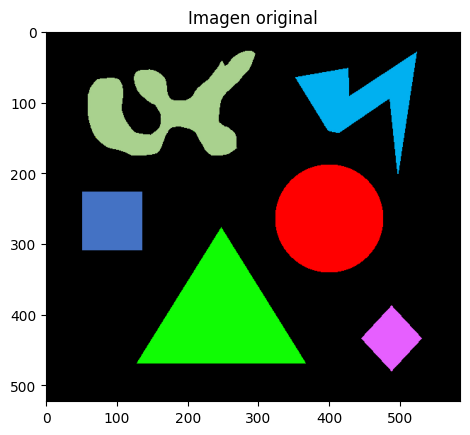

In [10]:
# Imaginamos que queremos segmentar únicamente el círculo
img = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb, cmap='gray')
plt.title('Imagen original')
plt.show()

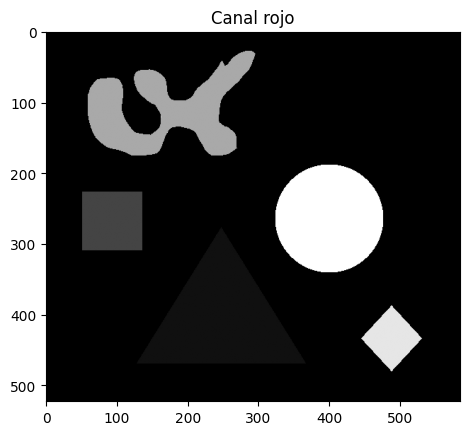

In [11]:
# Obtenemos el canal rojo
R = img[:,:,2]

plt.imshow(R, cmap='gray')
plt.title('Canal rojo')
plt.show()

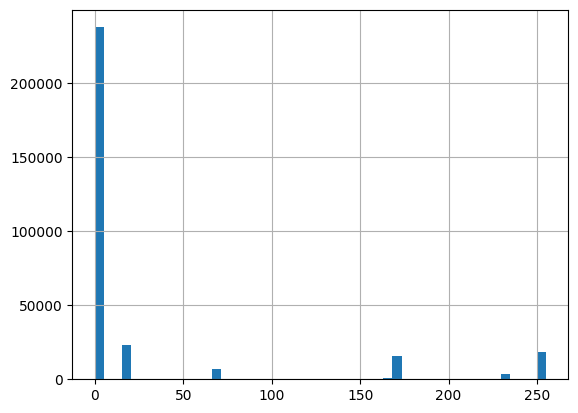

255


In [12]:
# Observamos el histograma del calan rojo
plt.hist(R.ravel(), bins=50)
plt.grid(True)
plt.show()
print(np.max(R))

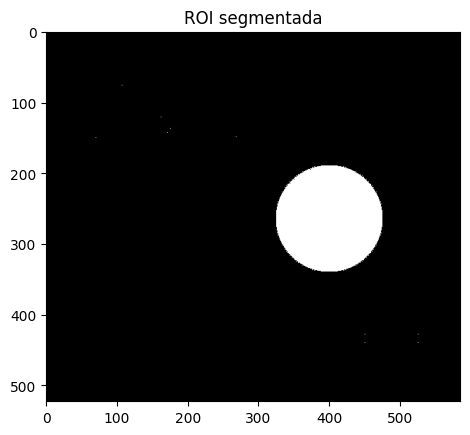

In [13]:
# Fijamos el umbral y extraemos la máscara
  # Queremos quedarnos con el elemento que tenga el valor más rojo
t=np.max(R)
mask = R.copy()
mask[mask<t] = 0

plt.imshow(mask, cmap='gray')
plt.title('ROI segmentada')
plt.show()

/tmp/ipykernel_304/1315111566.py:10: RuntimeWarning: invalid value encountered in cast
  CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')


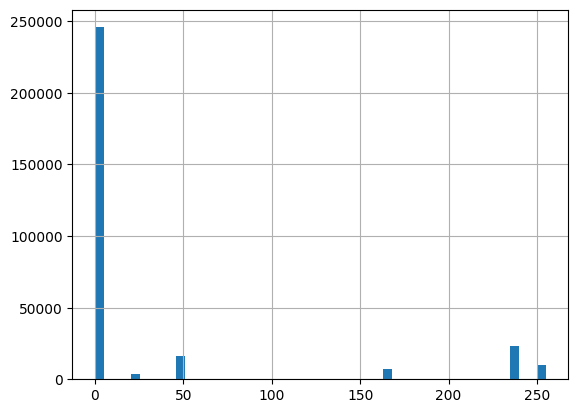

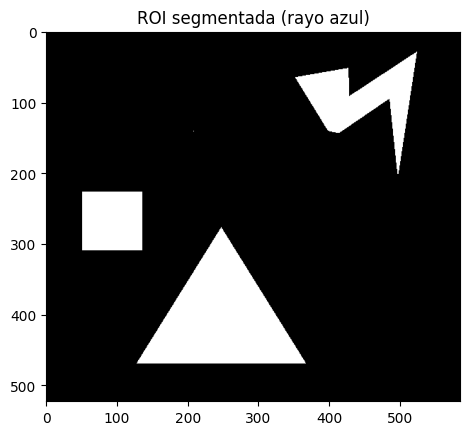

In [15]:
# Ejercicio: segmentar el rayo azul mediante espacio de color CMYK

# Función para convertir RGB normalizado a CMYK
def convert_to_CMYK(rgb_p):
    with np.errstate(invalid='ignore', divide='ignore'):
        K = 1 - np.max(rgb_p, axis=2)
        C = (1 - rgb_p[:,:,0] - K) / (1 - K)
        M = (1 - rgb_p[:,:,1] - K) / (1 - K)
        Y = (1 - rgb_p[:,:,2] - K) / (1 - K)
    CMYK = (np.dstack((C, M, Y, K)) * 255).astype('uint8')
    return CMYK

# Leer y convertir la imagen a RGB normalizado
img   = cv2.imread('images/figuras.png')
rgb   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rgb_p = rgb.astype('uint8') / 255

# Extraer canales CMYK (colores secundarios) usando la función definida
CMYK = convert_to_CMYK(rgb_p)

# Extraer los canales los 4 canales
C, M, Y, K = cv2.split(CMYK)
#C = C.astype('uint8')

# Observamos el histograma
plt.hist(C.ravel(), bins=50)
plt.grid(True)
plt.show()
# Segmentar el rayo azul usando el canal C (Cyan)
# Motivo: el azul tiene R y G bajos → C y M altos en CMYK
# Otsu encuentra automáticamente el umbral óptimo
#_, mask = cv2.threshold(C, 0, 255, cv2.THRESH_OTSU)

# Visualizar la máscara resultante
plt.imshow(mask, cmap='gray')
plt.title('ROI segmentada (rayo azul)')
plt.show()

### SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES

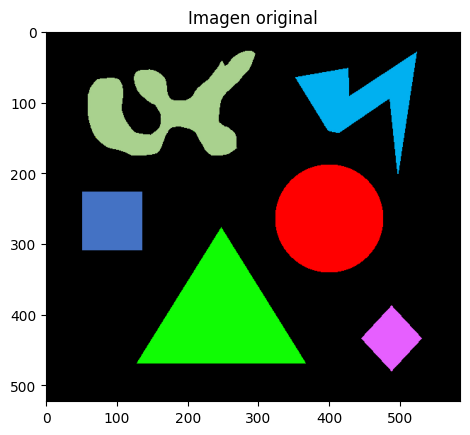

In [17]:
# SEGMENTACIÓN SEMÁNTICA CON DETECCIÓN DE BORDES

# Cargar imagen y convertir BGR → RGB para mostrar correctamente con matplotlib
img     = cv2.imread('images/figuras.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Mostrar imagen original antes de aplicar detección de bordes
plt.imshow(img_rgb)
plt.title('Imagen original')
plt.show()

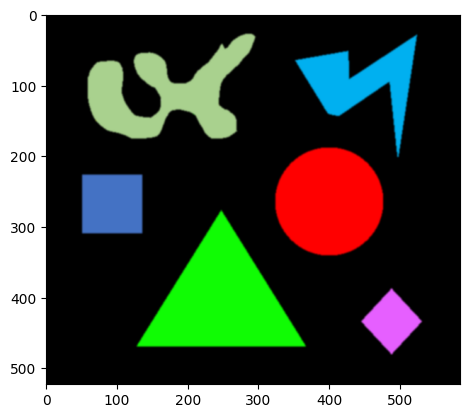

In [24]:
# Aplicamos un filtro gaussiano para emborronar las altas frecuencias
  # Esto lo hacemos porque calcular el gradiente sobre frecuencias altas puede ser muy ruidoso
img_gaus = cv2.GaussianBlur(img_rgb, (5,5), 0) # (5x5) es el tamaño del filtro y 0 es la desviación estándar
plt.imshow(img_gaus, cmap='gray')
plt.show()

In [21]:
# Ejemplo de porque queremos aplicar el filtro gaussiano
  # Para eliminar las altas frecuencias (problemáticas)
a = [55, 56, 55, 56, 57, 58, 56, 59, 58, 60, 61, 62, 61, 60]
a = np.array(a)
print(np.diff(a)) # hace la diferencia entre los elementos del vector

[ 1 -1  1  1  1 -2  3 -1  2  1  1 -1 -1]


In [ ]:
array = [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
kernel = [1, 1, 1] # en este caso, de tres en tres pixeles, a mayor tamaño mas objetos une

# Va evaluando tomando los máximos
# dilatacion: [0, 0, 0, 0, 1]

# Ento nos sirve para sacar píxeles de ruido

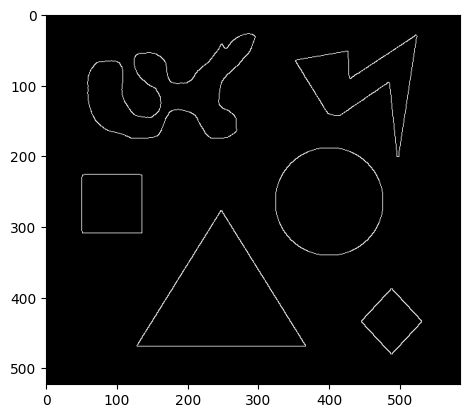

In [19]:
# Detección de bordes de Canny
canny = cv2.Canny(img_gaus, 255/3, 255) # minValue and maxValue. Canny recomienda que minValue sea 3 veces mayor que maxValue
  # Canny es un algoritmo de deteccion de bordes: indicamos valor minimo=3 y maximo=255
kernel = np.ones((2,2), 'uint8')
#canny = cv2.dilate(canny, kernel, iterations=2)
#canny = cv2.erode(canny, kernel, iterations=2)

plt.imshow(canny, cmap='gray')
plt.show()

/tmp/ipykernel_304/379968627.py:2: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_fill_holes as bfh


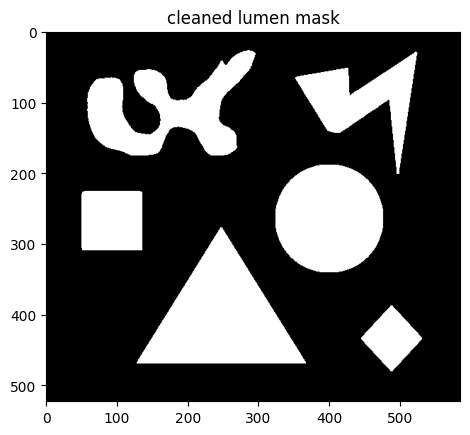

In [27]:
# Rellenar objetos (solo rellena si no están en contacto con el límite de la imagen)
from scipy.ndimage.morphology import binary_fill_holes as bfh
bordes = canny.copy()
filled_bordes = bfh(bordes)

plt.imshow(filled_bordes.astype('uint8'), cmap='gray')
plt.title('cleaned lumen mask')
plt.show()

# La ventaja de trabajar canny ha sido no definir los colores con las figuras que tratermos
  # Simplemente al jugar con los bordes ya hemos podido tomar las figuras

### SEGMENTACIÓN POR CRECIMIENTO DE REGIONES (region growing)

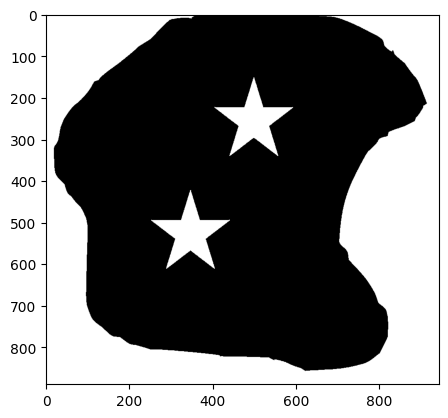

In [29]:
# Cargar imagen directamente en escala de grises
from skimage import io
import cv2
import numpy as np
import matplotlib.pyplot as plt

# El parámetro "0" equivale a cv2.IMREAD_GRAYSCALE
# Carga la imagen como matriz 2D (sin canales de color)
img = cv2.imread('images/estrellas.png', 0)

plt.imshow(img, cmap='gray')  # cmap='gray' necesario al ser imagen 2D
plt.show()

Introducir una semilla = introducir un pixel positivo.

La idea es hacer crecer el fondo negro

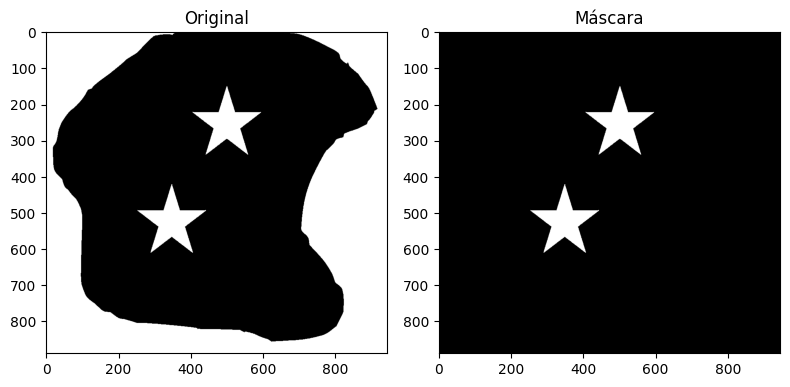

In [31]:
# RELLENO POR INUNDACIÓN (FLOOD FILL)

# Copia de la imagen para no modificar la original
mask = img.copy()

# Crear imagen de referencia negra con tamaño (h+2, w+2)
# El +2 es obligatorio en cv2.floodFill → actúa como borde de control
h, w = img.shape
ref = np.zeros((h+2, w+2), np.uint8)

# cv2.floodFill: rellena una región de color uniforme a partir de una semilla
# Parámetros:
#   mask      → imagen a rellenar
#   ref       → máscara auxiliar de control (debe ser h+2, w+2)
#   (0,0)     → semilla: punto de inicio del relleno (esquina superior izquierda)
#   0         → color con el que rellenar (0 = negro)
# Efecto: rellena todo el fondo conectado a (0,0) de negro → deja solo las estrellas
cv2.floodFill(mask, ref, (0,0), 0)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img, cmap='gray'),  ax[0].set_title('Original')
ax[1].imshow(mask, cmap='gray'), ax[1].set_title('Máscara')
plt.tight_layout()
plt.show()